In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [2]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [3]:
# Helper functions
def calculate_metrics(y_test, preds):
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2) Score: {r2:.2f}")

    return (mae, mse, rmse, r2)
    
def plot_pred_vs_true(y_test, preds):
    MIN_VALUE = 0
    MAX_VALUE = max(y_test)
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, preds)
    plt.plot([MIN_VALUE, MAX_VALUE], [MIN_VALUE, MAX_VALUE], '--k', label="Correct prediction")

    plt.title("Predicted vs. True Plot")
    plt.xlabel('True Price')
    plt.ylabel('Predicted Price')
    plt.legend()
    plt.tight_layout()

def plot_residual(y_test, preds):
    residuals = y_test - preds
    plt.figure(figsize=(8, 8))
    plt.xlabel('Price')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')
    plt.scatter(preds, residuals)
    plt.axhline(0, linestyle="--")

def get_z_score_scale(dataset, feature_name):
    feature = list(dataset[feature_name])
    mu = np.mean(feature)
    std = np.std(feature)
    return mu, std

def z_score_scale(dataset, feature_name, mu, std):
    dataset[feature_name] = [round((i - mu) / std, 2) for i in dataset[feature_name]]

# Helper functions - Data imputation:
def get_mode(dataset, feature_name):
    mode = dataset[feature_name].mode(dropna=True)
    return mode.iloc[0] if not mode.empty else "unknown"

def get_mean(dataset, feature_name):
    return round(np.nanmean(dataset[feature_name]), 1)

def fill_value(dataset, feature_name, value):
    dataset[feature_name] = dataset[feature_name].fillna(value)

def fill_mode(dataset, feature_name):
    '''
    The mode is used for imputation when dealing with categorical data 
    or data with a limited set of distinct categories, 
    like car types, colors, or city names.
    '''
    feature = list(dataset[feature_name])
    frequencies = {}
    for e in set(feature):
        frequencies[e] = feature.count(e)
    max_element = max(frequencies, key=frequencies.get)
    for i, e in enumerate(feature):
        if pd.isna(e):
            feature[i] = max_element
    
    dataset[feature_name] = feature

# Helper functions - Conversion
def category_to_num(dataset, feature_name):
    feature = list(dataset[feature_name])
    elements = set(feature)
    
    categories = {}
    for i, e in enumerate(elements):
        if not categories.get(e):
            categories[e] = float(i)

    for i, e in enumerate(feature):
        feature[i] = categories[e]
    
    dataset[feature_name] = feature

def remove_row_due_missing_element(dataset, feature_name):
    return dataset.dropna(subset=[feature_name])

def one_hot_encode_train_test(X_train, X_test, feature_name):
    train_feature = X_train[[feature_name]]
    test_feature = X_test[[feature_name]]

    encoder.fit(train_feature)

    encoded_columns = encoder.get_feature_names_out([feature_name])

    train_encoded = encoder.transform(train_feature)
    test_encoded = encoder.transform(test_feature)

    train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_columns, index=X_train.index)
    test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_columns, index=X_test.index)

    X_train = pd.concat([X_train.drop(columns=[feature_name]), train_encoded_df], axis=1)

    X_test = pd.concat([X_test.drop(columns=[feature_name]), test_encoded_df], axis=1)

    return X_train, X_test


In [4]:
# Download aws s3 cp "s3://$CURATED_BUCKET/curated/test/sample_input.csv" ./processed_output.csv
dataset = pd.read_csv("./processed_output.csv")
independent_variables = dataset.drop(columns=["price"])
dependent_variable = dataset["price"]
seed=42

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   carname           235 non-null    str    
 1   fueltype          235 non-null    str    
 2   aspiration        235 non-null    str    
 3   doornumber        235 non-null    str    
 4   carbody           235 non-null    str    
 5   drivewheel        235 non-null    str    
 6   enginelocation    226 non-null    str    
 7   wheelbase         235 non-null    float64
 8   color             235 non-null    str    
 9   carlength         231 non-null    float64
 10  carwidth          235 non-null    float64
 11  carheight         235 non-null    float64
 12  curbweight        235 non-null    int64  
 13  cylindernumber    227 non-null    float64
 14  enginesize        235 non-null    int64  
 15  compressionratio  235 non-null    float64
 16  horsepower        235 non-null    float64
 17  peakrpm 

In [6]:
categorical_features = ["carname", "fueltype", "aspiration", "doornumber", "carbody", "drivewheel", "enginelocation", "color"]

# To avoid data leakage, we first split the data into train and test sets. I will use 80% train, and 20% test set.
X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, random_state=seed, test_size=0.2, shuffle=True)

In [7]:
X_train.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg
count,188.000000,185.000000,188.000000,188.000000,188.000000,183.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,98.380319,173.285405,65.696277,53.600532,2514.223404,4.284153,123.446809,10.160266,100.553191,5108.510638,25.494681,31.111702
std,5.875025,11.877443,2.005457,2.491429,486.351750,0.905490,36.861242,4.038651,34.076076,482.813629,6.389746,6.720013
min,86.600000,141.100000,60.300000,48.800000,1488.000000,2.000000,61.000000,7.000000,48.000000,4150.000000,14.000000,16.000000
25%,94.500000,166.300000,64.000000,51.600000,2143.750000,4.000000,97.750000,8.500000,70.000000,4800.000000,20.750000,25.000000
50%,96.500000,172.400000,65.400000,53.800000,2403.000000,4.000000,110.500000,9.000000,94.500000,5100.000000,25.000000,30.000000
75%,100.400000,178.200000,66.500000,55.500000,2826.250000,4.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,34.500000
max,120.900000,208.100000,72.000000,59.800000,4066.000000,8.000000,308.000000,23.000000,207.000000,6600.000000,49.000000,54.000000


In [8]:
# DATA IMPUTATION
# https://medium.com/the-modern-scientist/navigating-the-pitfalls-of-data-leakage-in-imputing-missing-values-351091a3963e

for feature in ["fueltype", "carbody", "enginelocation"]:
    value = get_mode(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

for feature in ["carlength", "cylindernumber", "horsepower"]:
    value = get_mean(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

# DATA CONVERSION
for feature in categorical_features:
    X_train, X_test = one_hot_encode_train_test(X_train, X_test, feature)

In [9]:
# Scale the data
features_to_scale = ["wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "compressionratio", "horsepower", "peakrpm", "highwaympg", "citympg"]

# Scale train
for feature in features_to_scale:
    mu, std = get_z_score_scale(X_train, feature)
    z_score_scale(X_train, feature, mu, std)
    z_score_scale(X_test, feature, mu, std)

In [10]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 188 entries, 117 to 102
Data columns (total 70 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   wheelbase             188 non-null    float64
 1   carlength             188 non-null    float64
 2   carwidth              188 non-null    float64
 3   carheight             188 non-null    float64
 4   curbweight            188 non-null    float64
 5   cylindernumber        188 non-null    float64
 6   enginesize            188 non-null    float64
 7   compressionratio      188 non-null    float64
 8   horsepower            188 non-null    float64
 9   peakrpm               188 non-null    float64
 10  citympg               188 non-null    float64
 11  highwaympg            188 non-null    float64
 12  carname_Nissan        188 non-null    float64
 13  carname_alfa-romero   188 non-null    float64
 14  carname_audi          188 non-null    float64
 15  carname_bmw           188 non-null   

In [11]:
simple_linear_model = LinearRegression()
simple_linear_model.fit(X_train, y_train)
simple_linear_model_preds = simple_linear_model.predict(X_test)
simple_linear_model_preds_on_train = simple_linear_model.predict(X_train)

print("Train set performance: \n")
mae, mse, rmse, r2 = calculate_metrics(y_test=y_train, preds=simple_linear_model_preds_on_train)
print("\nTest set performance: \n")
calculate_metrics(y_test=y_test, preds=simple_linear_model_preds)

Train set performance: 

Mean Absolute Error (MAE): 970.70
Mean Squared Error (MSE): 1768543.67
Root Mean Squared Error (RMSE): 1329.87
R-squared (R2) Score: 0.96

Test set performance: 

Mean Absolute Error (MAE): 1835.87
Mean Squared Error (MSE): 10110899.73
Root Mean Squared Error (RMSE): 3179.76
R-squared (R2) Score: 0.89


(1835.8709553308151, 10110899.73147783, 3179.7640999731143, 0.8933653147502665)

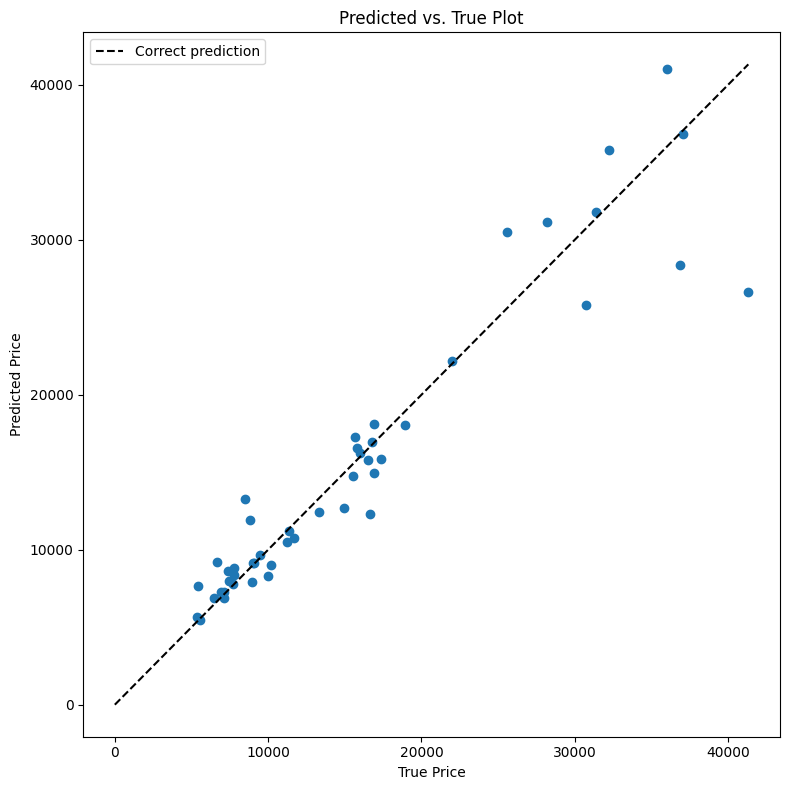

In [12]:
plot_pred_vs_true(y_test, simple_linear_model_preds)

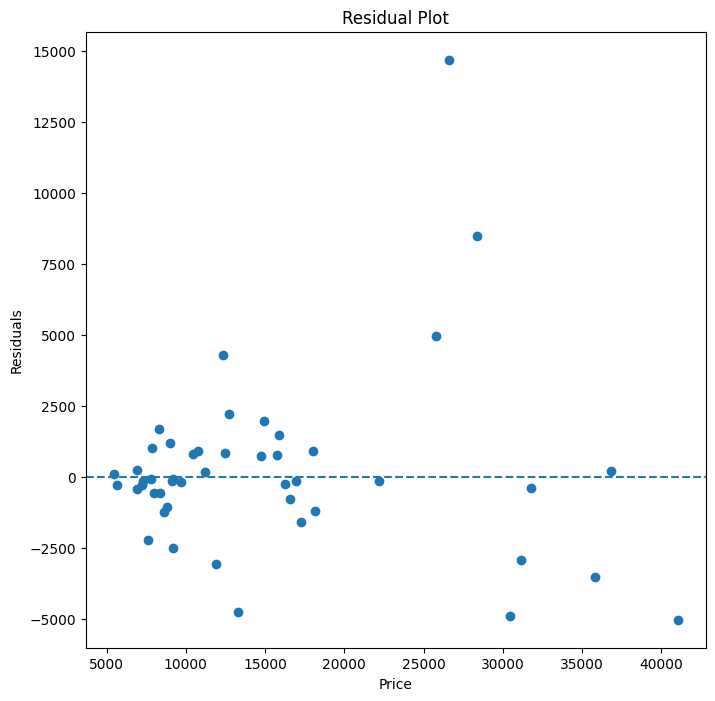

In [13]:
plot_residual(y_test, simple_linear_model_preds)